# 10 — Train Silhouette GaitGL-style Expert — FULL FIXED

এই notebook আপনার YOLO silhouette dataset দিয়ে **silhouette-only expert** train করবে।

Input:

```text
/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/train_LT_fusion.csv
```

Silhouette `.npz` expected:

```text
silhouettes: T × 64 × 44, uint8, values 0/255
```

Model:

```text
GaitGL-style global-local 3D CNN + horizontal pyramid pooling
CE loss + batch-hard triplet loss
```

Outputs:

```text
checkpoints/gaitgl_LT_silhouette_last.pth
checkpoints/gaitgl_LT_silhouette_full_last.pth
checkpoints/gaitgl_LT_silhouette_best_loss.pth
checkpoints/gaitgl_LT_silhouette_best_train_acc.pth
logs/gaitgl_LT_silhouette_train_log.csv
```

Important:

- This is a **GaitGL-style practical implementation**, not an official OpenGait code copy.
- It is designed for your RTX 3060 6GB laptop GPU.
- Default batch is safe: `P=8, K=2`, batch size = 16.
- First run the tiny sanity test. Then set:

```python
RUN_TINY_SANITY_TEST = False
RUN_FULL_TRAINING = True
```

In [1]:
# ============================================================
# CELL 1 — Imports, paths, config
# ============================================================

from pathlib import Path
import os
import time
import math
import random
import json
import gc
from collections import defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

try:
    from tqdm.notebook import tqdm
except Exception:
    try:
        from tqdm import tqdm
    except Exception:
        def tqdm(x, *args, **kwargs):
            return x

import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
FUSION_SPLIT_DIR = EXP_DIR / "data" / "fusion_splits"
CHECKPOINT_DIR = EXP_DIR / "checkpoints"
LOG_DIR = EXP_DIR / "logs"
RESULT_DIR = EXP_DIR / "results"

for d in [CHECKPOINT_DIR, LOG_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SPLIT_NAME = "LT"
TRAIN_CSV = FUSION_SPLIT_DIR / f"train_{SPLIT_NAME}_fusion.csv"

# -----------------------------
# Run controls
# -----------------------------
RUN_TINY_SANITY_TEST = False
RUN_FULL_TRAINING = True

RESUME_FROM_FULL = None
# Example:
# RESUME_FROM_FULL = CHECKPOINT_DIR / "gaitgl_LT_silhouette_full_last.pth"

RUN_NAME = f"gaitgl_{SPLIT_NAME}_silhouette"

# -----------------------------
# Data config
# -----------------------------
SEQ_LEN = 60
SIL_H = 64
SIL_W = 44

# Keep this False for first stable baseline.
USE_RANDOM_HORIZONTAL_FLIP = False

# -----------------------------
# Model config
# -----------------------------
EMBEDDING_DIM = 256
CHANNELS = [32, 64, 128, 128]
HPP_BINS = [1, 2, 4, 8]
DROPOUT = 0.10

# -----------------------------
# Training config, RTX 3060 6GB safe defaults
# -----------------------------
P = 8
K = 2
BATCH_SIZE = P * K

MAX_STEPS = 30000
STEPS_PER_EPOCH = 500

BASE_LR = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_STEPS = 1000

TRIPLET_MARGIN = 0.20
TRIPLET_WEIGHT_MAX = 0.20
TRIPLET_WARMUP_STEPS = 5000

CE_LABEL_SMOOTHING = 0.10

LOG_EVERY = 50
SAVE_EVERY = 1000

NUM_WORKERS = 2
PIN_MEMORY = True

USE_AMP = True
GRAD_CLIP_NORM = 5.0

SEED = 42

# -----------------------------
# Tiny sanity config
# -----------------------------
TINY_NUM_SUBJECTS = 4
TINY_SAMPLES_PER_SUBJECT = 8
TINY_P = 4
TINY_K = 2
TINY_MAX_STEPS = 500
TINY_LR = 1e-3

# -----------------------------
# Device setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print("=" * 80)
print("Silhouette GaitGL-style Expert Training")
print("=" * 80)
print("EXP_DIR    :", EXP_DIR)
print("TRAIN_CSV  :", TRAIN_CSV)
print("RUN_NAME   :", RUN_NAME)
print("Device     :", device)
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))
print("SEQ_LEN    :", SEQ_LEN)
print("Silhouette :", f"{SIL_H}x{SIL_W}")
print("P,K,B      :", P, K, BATCH_SIZE)
print("=" * 80)

assert TRAIN_CSV.exists(), f"Missing train fusion CSV: {TRAIN_CSV}"

Silhouette GaitGL-style Expert Training
EXP_DIR    : /media/wadud/DriveUbuntu/GaitRecognition 2.0
TRAIN_CSV  : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/train_LT_fusion.csv
RUN_NAME   : gaitgl_LT_silhouette
Device     : cuda
GPU        : NVIDIA GeForce RTX 3060 Laptop GPU
SEQ_LEN    : 60
Silhouette : 64x44
P,K,B      : 8 2 16


In [2]:
# ============================================================
# CELL 2 — Load and validate training CSV
# ============================================================

csv_dtype = {
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
    "pose_path": str,
    "silhouette_path": str,
}

df_train = pd.read_csv(TRAIN_CSV, dtype=csv_dtype)

print("Raw training rows:", len(df_train))
display(df_train.head())

required_cols = ["subject", "condition", "seq", "view", "silhouette_path"]
missing_cols = [c for c in required_cols if c not in df_train.columns]
assert not missing_cols, f"Missing columns in {TRAIN_CSV}: {missing_cols}"

# Remove invalid rows safely.
df_train = df_train.dropna(subset=["subject", "silhouette_path"]).copy()
df_train["silhouette_path"] = df_train["silhouette_path"].astype(str)

# Check paths.
exists_mask = df_train["silhouette_path"].apply(lambda p: Path(p).exists())
missing_paths = df_train[~exists_mask].copy()

if len(missing_paths) > 0:
    missing_csv = LOG_DIR / f"{RUN_NAME}_missing_silhouette_paths.csv"
    missing_paths.to_csv(missing_csv, index=False)
    print("[WARNING] Missing silhouette paths:", len(missing_paths))
    print("Saved:", missing_csv)

df_train = df_train[exists_mask].copy().reset_index(drop=True)

subjects = sorted(df_train["subject"].unique().tolist())
subject_to_label = {s: i for i, s in enumerate(subjects)}
label_to_subject = {i: s for s, i in subject_to_label.items()}

df_train["label"] = df_train["subject"].map(subject_to_label).astype(int)

num_classes = len(subjects)

print("Clean training rows:", len(df_train))
print("Num train subjects :", num_classes)
print("Rows per subject summary:")
display(df_train.groupby("subject").size().describe())

assert num_classes >= P, f"Need at least P={P} subjects, found {num_classes}"
assert df_train.groupby("subject").size().min() >= K, f"Every subject needs at least K={K} samples"

# Save label mapping.
label_map_path = LOG_DIR / f"{RUN_NAME}_label_mapping.json"
with open(label_map_path, "w") as f:
    json.dump({
        "subject_to_label": subject_to_label,
        "label_to_subject": label_to_subject,
    }, f, indent=2)

print("Saved label mapping:", label_map_path)

Raw training rows: 8139


,split_pose_path,subject,condition,seq,view,pose_path,silhouette_path,T_pose,T_silhouette,T_common,T_diff,alignment_status,sil_valid_frame_ratio,sil_mean_det_score,sil_mean_mask_area
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99.0,99.0,99.0,0.0,exact,1.000000,0.910541,4039.515137
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,102.0,102.0,102.0,0.0,exact,1.000000,0.905187,4417.048828
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99.0,99.0,99.0,0.0,exact,0.969697,0.862985,3496.373779
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106.0,106.0,106.0,0.0,exact,0.943396,0.839839,2664.773682
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106.0,106.0,106.0,0.0,exact,0.811321,0.682147,2239.179199


Clean training rows: 8139
Num train subjects : 74
Rows per subject summary:


count     74.000000
mean     109.986486
std        0.116248
min      109.000000
25%      110.000000
50%      110.000000
75%      110.000000
max      110.000000
dtype: float64

Saved label mapping: /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaitgl_LT_silhouette_label_mapping.json


In [3]:
# ============================================================
# CELL 3 — Dataset and P-K batch sampler
# ============================================================

def crop_or_pad_silhouette_sequence(S, seq_len=60, random_crop=True):
    # S: T x H x W
    T = S.shape[0]

    if T == seq_len:
        return S

    if T > seq_len:
        if random_crop:
            start = np.random.randint(0, T - seq_len + 1)
        else:
            start = max(0, (T - seq_len) // 2)
        return S[start:start + seq_len]

    # Pad by repeating last frame.
    pad_len = seq_len - T
    pad = np.repeat(S[-1:], pad_len, axis=0)
    return np.concatenate([S, pad], axis=0)

def maybe_random_shift(S, max_shift=2):
    # Small horizontal shift augmentation.
    if max_shift <= 0:
        return S

    shift = np.random.randint(-max_shift, max_shift + 1)
    if shift == 0:
        return S

    out = np.zeros_like(S)

    if shift > 0:
        out[:, :, shift:] = S[:, :, :-shift]
    else:
        out[:, :, :shift] = S[:, :, -shift:]

    return out

class SilhouetteDataset(Dataset):
    def __init__(
        self,
        df,
        seq_len=60,
        train=True,
        use_random_horizontal_flip=False,
        random_shift_pixels=2,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.seq_len = seq_len
        self.train = train
        self.use_random_horizontal_flip = use_random_horizontal_flip
        self.random_shift_pixels = random_shift_pixels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["silhouette_path"]

        data = np.load(path)
        S = data["silhouettes"].astype(np.float32)

        # Convert 0/255 to 0/1.
        if S.max() > 1.5:
            S = S / 255.0

        S = crop_or_pad_silhouette_sequence(
            S,
            seq_len=self.seq_len,
            random_crop=self.train,
        )

        if self.train:
            S = maybe_random_shift(S, max_shift=self.random_shift_pixels)

            if self.use_random_horizontal_flip and random.random() < 0.5:
                S = S[:, :, ::-1].copy()

        S = np.ascontiguousarray(S, dtype=np.float32)

        label = int(row["label"])

        return {
            "silhouette": torch.from_numpy(S),  # T x H x W
            "label": torch.tensor(label, dtype=torch.long),
            "subject": str(row["subject"]),
            "condition": str(row["condition"]),
            "seq": str(row["seq"]),
            "view": str(row["view"]),
            "path": str(path),
        }

class PKBatchSampler(Sampler):
    # Randomly sample P identities and K samples per identity.
    def __init__(self, labels, p=8, k=2, steps_per_epoch=500):
        self.labels = np.asarray(labels)
        self.p = int(p)
        self.k = int(k)
        self.steps_per_epoch = int(steps_per_epoch)

        self.label_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.label_to_indices[int(label)].append(idx)

        self.unique_labels = sorted(list(self.label_to_indices.keys()))
        self.unique_labels = [lab for lab in self.unique_labels if len(self.label_to_indices[lab]) >= 1]

        assert len(self.unique_labels) >= self.p, (
            f"Need at least p={self.p} labels, found {len(self.unique_labels)}"
        )

    def __len__(self):
        return self.steps_per_epoch

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            selected_labels = random.sample(self.unique_labels, self.p)
            batch = []

            for lab in selected_labels:
                indices = self.label_to_indices[lab]

                if len(indices) >= self.k:
                    chosen = random.sample(indices, self.k)
                else:
                    chosen = random.choices(indices, k=self.k)

                batch.extend(chosen)

            random.shuffle(batch)
            yield batch

def make_loader(df, p=P, k=K, steps_per_epoch=STEPS_PER_EPOCH, train=True, num_workers=NUM_WORKERS):
    dataset = SilhouetteDataset(
        df,
        seq_len=SEQ_LEN,
        train=train,
        use_random_horizontal_flip=USE_RANDOM_HORIZONTAL_FLIP,
        random_shift_pixels=2 if train else 0,
    )

    sampler = PKBatchSampler(
        labels=df["label"].values,
        p=p,
        k=k,
        steps_per_epoch=steps_per_epoch,
    )

    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=num_workers,
        pin_memory=PIN_MEMORY,
        persistent_workers=(num_workers > 0),
    )

    return dataset, loader

# Quick data test
tmp_dataset = SilhouetteDataset(df_train.iloc[:10].copy(), seq_len=SEQ_LEN, train=True)
sample = tmp_dataset[0]
print("Sample silhouette shape:", sample["silhouette"].shape)
print("Sample label:", sample["label"])
print("Sample path:", sample["path"])

assert tuple(sample["silhouette"].shape) == (SEQ_LEN, SIL_H, SIL_W)

Sample silhouette shape: torch.Size([60, 64, 44])
Sample label: tensor(0)
Sample path: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44/001/bg-01/000.npz


In [4]:
# ============================================================
# CELL 4 — GaitGL-style model
# ============================================================

class ConvBNAct3D(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=(3, 3, 3),
        stride=(1, 1, 1),
        padding=(1, 1, 1),
        dropout=0.0,
    ):
        super().__init__()
        self.conv = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False,
        )
        self.bn = nn.BatchNorm3d(out_channels)
        self.act = nn.Mish()
        self.drop = nn.Dropout3d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.drop(x)
        return x

class Residual3DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=(1, 1, 1), dropout=0.0):
        super().__init__()

        self.conv1 = ConvBNAct3D(
            in_channels,
            out_channels,
            kernel_size=(3, 3, 3),
            stride=stride,
            padding=(1, 1, 1),
            dropout=dropout,
        )

        self.conv2 = nn.Sequential(
            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=(3, 3, 3),
                stride=(1, 1, 1),
                padding=(1, 1, 1),
                bias=False,
            ),
            nn.BatchNorm3d(out_channels),
        )

        if in_channels != out_channels or stride != (1, 1, 1):
            self.shortcut = nn.Sequential(
                nn.Conv3d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm3d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

        self.act = nn.Mish()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.act(out + identity)
        return out

class HorizontalPyramidPooling3D(nn.Module):
    # HPP over height dimension.
    # Input:  B x C x T x H x W
    # Output: B x P_parts x C
    def __init__(self, bins=(1, 2, 4, 8)):
        super().__init__()
        self.bins = list(bins)

    def forward(self, x):
        B, C, T, H, W = x.shape
        part_features = []

        for bin_count in self.bins:
            for i in range(bin_count):
                h_start = int(round(i * H / bin_count))
                h_end = int(round((i + 1) * H / bin_count))
                h_end = max(h_end, h_start + 1)

                part = x[:, :, :, h_start:h_end, :]

                mean_pool = part.mean(dim=(2, 3, 4))
                max_pool = part.amax(dim=(2, 3, 4))
                pooled = mean_pool + max_pool

                part_features.append(pooled)

        out = torch.stack(part_features, dim=1)  # B x P x C
        return out

class GaitGLLiteBackbone(nn.Module):
    # Practical GaitGL-style silhouette expert:
    # - 3D spatiotemporal CNN
    # - global-local horizontal pyramid pooling
    # - part-wise projection
    # - final normalized embedding
    def __init__(
        self,
        embedding_dim=256,
        channels=(32, 64, 128, 128),
        hpp_bins=(1, 2, 4, 8),
        dropout=0.1,
    ):
        super().__init__()

        c1, c2, c3, c4 = channels

        self.stem = nn.Sequential(
            ConvBNAct3D(1, c1, kernel_size=(3, 5, 5), padding=(1, 2, 2), dropout=0.0),
            Residual3DBlock(c1, c1, stride=(1, 1, 1), dropout=dropout),
        )

        # Downsample spatial only, preserve temporal length.
        self.layer1 = nn.Sequential(
            Residual3DBlock(c1, c2, stride=(1, 2, 2), dropout=dropout),
            Residual3DBlock(c2, c2, stride=(1, 1, 1), dropout=dropout),
        )

        self.layer2 = nn.Sequential(
            Residual3DBlock(c2, c3, stride=(1, 2, 2), dropout=dropout),
            Residual3DBlock(c3, c3, stride=(1, 1, 1), dropout=dropout),
        )

        # Local temporal aggregation block.
        self.layer3 = nn.Sequential(
            ConvBNAct3D(c3, c4, kernel_size=(3, 3, 3), padding=(1, 1, 1), dropout=dropout),
            Residual3DBlock(c4, c4, stride=(1, 1, 1), dropout=dropout),
        )

        self.hpp = HorizontalPyramidPooling3D(bins=hpp_bins)

        self.part_norm = nn.LayerNorm(c4)
        self.part_fc = nn.Linear(c4, embedding_dim, bias=False)
        self.embedding_bn = nn.BatchNorm1d(embedding_dim)

    def forward(self, x):
        # x: B x T x H x W
        if x.ndim != 4:
            raise ValueError(f"Expected input BxTxHxW, got {x.shape}")

        x = x.unsqueeze(1)  # B x 1 x T x H x W

        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        parts = self.hpp(x)  # B x P_parts x C
        parts = self.part_norm(parts)
        parts = self.part_fc(parts)  # B x P_parts x embedding_dim

        emb = parts.mean(dim=1)  # B x embedding_dim
        emb = self.embedding_bn(emb)
        emb = F.normalize(emb, p=2, dim=1)

        return emb

class GaitGLClassifier(nn.Module):
    def __init__(self, backbone, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        emb = self.backbone(x)
        logits = self.classifier(emb)
        return emb, logits

def build_model(num_classes):
    backbone = GaitGLLiteBackbone(
        embedding_dim=EMBEDDING_DIM,
        channels=CHANNELS,
        hpp_bins=HPP_BINS,
        dropout=DROPOUT,
    )

    model = GaitGLClassifier(
        backbone=backbone,
        embedding_dim=EMBEDDING_DIM,
        num_classes=num_classes,
    )

    return model

# Forward test
model_test = build_model(num_classes=num_classes).to(device)
model_test.eval()

with torch.no_grad():
    dummy = torch.randn(2, SEQ_LEN, SIL_H, SIL_W).to(device)
    emb, logits = model_test(dummy)

print("Embedding shape:", emb.shape)
print("Logits shape   :", logits.shape)

assert emb.shape == (2, EMBEDDING_DIM)
assert logits.shape == (2, num_classes)

del model_test, dummy, emb, logits
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Embedding shape: torch.Size([2, 256])
Logits shape   : torch.Size([2, 74])


In [5]:
# ============================================================
# CELL 5 — Losses, optimizer, scheduler, checkpoint helpers
# ============================================================

def batch_hard_triplet_loss(embeddings, labels, margin=0.2):
    # embeddings: B x D, normalized
    labels = labels.view(-1)
    B = embeddings.size(0)

    dist = torch.cdist(embeddings, embeddings, p=2)  # B x B

    same = labels.unsqueeze(0) == labels.unsqueeze(1)
    diff = ~same

    eye = torch.eye(B, dtype=torch.bool, device=embeddings.device)
    same = same & (~eye)

    # Hardest positive: largest positive distance.
    pos_dist = dist.masked_fill(~same, -1.0)
    hardest_pos, _ = pos_dist.max(dim=1)

    # Hardest negative: smallest negative distance.
    neg_dist = dist.masked_fill(~diff, 1e9)
    hardest_neg, _ = neg_dist.min(dim=1)

    valid = hardest_pos >= 0

    if valid.sum() == 0:
        return embeddings.sum() * 0.0

    loss = F.relu(hardest_pos[valid] - hardest_neg[valid] + margin)
    return loss.mean()

def get_lr(step, max_steps, base_lr, warmup_steps):
    if step < warmup_steps:
        return base_lr * float(step + 1) / float(max(1, warmup_steps))

    progress = float(step - warmup_steps) / float(max(1, max_steps - warmup_steps))
    progress = min(max(progress, 0.0), 1.0)

    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

def get_triplet_weight(step):
    if step < TRIPLET_WARMUP_STEPS:
        return TRIPLET_WEIGHT_MAX * float(step + 1) / float(max(1, TRIPLET_WARMUP_STEPS))
    return TRIPLET_WEIGHT_MAX

def set_optimizer_lr(optimizer, lr):
    for group in optimizer.param_groups:
        group["lr"] = lr

def make_optimizer(model, base_lr=BASE_LR, weight_decay=WEIGHT_DECAY):
    return torch.optim.AdamW(
        model.parameters(),
        lr=base_lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
    )

def get_autocast_context():
    if device.type == "cuda" and USE_AMP:
        try:
            return torch.amp.autocast("cuda", enabled=True)
        except Exception:
            return torch.cuda.amp.autocast(enabled=True)

    try:
        return torch.amp.autocast("cuda", enabled=False)
    except Exception:
        return torch.cuda.amp.autocast(enabled=False)

def make_grad_scaler():
    if device.type == "cuda" and USE_AMP:
        try:
            return torch.amp.GradScaler("cuda", enabled=True)
        except Exception:
            return torch.cuda.amp.GradScaler(enabled=True)

    try:
        return torch.amp.GradScaler("cuda", enabled=False)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=False)

def save_checkpoint(
    model,
    optimizer,
    scaler,
    step,
    best_loss,
    best_acc,
    run_name,
    label_mapping,
    full=True,
    suffix="last",
):
    if full:
        path = CHECKPOINT_DIR / f"{run_name}_full_{suffix}.pth"
        payload = {
            "checkpoint_type": "full_gaitgl_silhouette_with_classifier",
            "step": step,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict() if optimizer is not None else None,
            "scaler": scaler.state_dict() if scaler is not None else None,
            "best_loss": best_loss,
            "best_acc": best_acc,
            "label_mapping": label_mapping,
            "config": {
                "seq_len": SEQ_LEN,
                "sil_h": SIL_H,
                "sil_w": SIL_W,
                "embedding_dim": EMBEDDING_DIM,
                "channels": CHANNELS,
                "hpp_bins": HPP_BINS,
                "dropout": DROPOUT,
                "num_classes": model.classifier.out_features,
                "run_name": run_name,
            },
        }
    else:
        path = CHECKPOINT_DIR / f"{run_name}_{suffix}.pth"
        payload = {
            "checkpoint_type": "eval_backbone_only_gaitgl_silhouette",
            "step": step,
            "model": model.backbone.state_dict(),
            "best_loss": best_loss,
            "best_acc": best_acc,
            "label_mapping": label_mapping,
            "config": {
                "seq_len": SEQ_LEN,
                "sil_h": SIL_H,
                "sil_w": SIL_W,
                "embedding_dim": EMBEDDING_DIM,
                "channels": CHANNELS,
                "hpp_bins": HPP_BINS,
                "dropout": DROPOUT,
                "run_name": run_name,
            },
        }

    torch.save(payload, path)
    return path

def load_full_checkpoint(path, model, optimizer=None, scaler=None):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"], strict=True)

    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])

    if scaler is not None and ckpt.get("scaler") is not None:
        scaler.load_state_dict(ckpt["scaler"])

    return ckpt

def batch_accuracy(logits, labels):
    pred = logits.argmax(dim=1)
    return (pred == labels).float().mean().item()

In [6]:
# ============================================================
# CELL 6 — Training loop
# ============================================================

def train_model(
    df_train_full,
    num_classes,
    run_name,
    max_steps,
    p,
    k,
    steps_per_epoch,
    resume_from=None,
    tiny=False,
):
    model = build_model(num_classes=num_classes).to(device)
    optimizer = make_optimizer(model, base_lr=TINY_LR if tiny else BASE_LR)
    scaler = make_grad_scaler()

    start_step = 0
    best_loss = float("inf")
    best_acc = 0.0

    label_mapping = {
        "subject_to_label": subject_to_label.copy(),
        "label_to_subject": label_to_subject.copy(),
    }

    if resume_from is not None:
        resume_from = Path(resume_from)
        print("Resuming from:", resume_from)
        ckpt = load_full_checkpoint(resume_from, model, optimizer, scaler)
        start_step = int(ckpt.get("step", 0)) + 1
        best_loss = float(ckpt.get("best_loss", float("inf")))
        best_acc = float(ckpt.get("best_acc", 0.0))
        print("Resumed step:", start_step, "best_loss:", best_loss, "best_acc:", best_acc)

    criterion_ce = nn.CrossEntropyLoss(label_smoothing=CE_LABEL_SMOOTHING)

    dataset, loader = make_loader(
        df_train_full,
        p=p,
        k=k,
        steps_per_epoch=steps_per_epoch,
        train=True,
        num_workers=NUM_WORKERS,
    )

    loader_iter = iter(loader)

    log_rows = []
    log_csv = LOG_DIR / f"{run_name}_train_log.csv"

    model.train()
    start_time = time.time()

    pbar = tqdm(
        range(start_step, max_steps),
        total=max_steps - start_step,
        desc=run_name,
    )

    for step in pbar:
        try:
            batch = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loader)
            batch = next(loader_iter)

        x = batch["silhouette"].float().to(device, non_blocking=True)  # B x T x H x W
        y = batch["label"].long().to(device, non_blocking=True)

        lr = get_lr(
            step,
            max_steps=max_steps,
            base_lr=TINY_LR if tiny else BASE_LR,
            warmup_steps=max(50, min(WARMUP_STEPS, max_steps // 10)),
        )
        set_optimizer_lr(optimizer, lr)

        tri_weight = 0.0 if tiny else get_triplet_weight(step)

        optimizer.zero_grad(set_to_none=True)

        with get_autocast_context():
            emb, logits = model(x)
            ce_loss = criterion_ce(logits, y)
            tri_loss = batch_hard_triplet_loss(emb, y, margin=TRIPLET_MARGIN)
            loss = ce_loss + tri_weight * tri_loss

        scaler.scale(loss).backward()

        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        acc = batch_accuracy(logits.detach(), y)
        elapsed = time.time() - start_time

        if float(loss.item()) < best_loss:
            best_loss = float(loss.item())

            if not tiny:
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    scaler=scaler,
                    step=step,
                    best_loss=best_loss,
                    best_acc=best_acc,
                    run_name=run_name,
                    label_mapping=label_mapping,
                    full=False,
                    suffix="best_loss",
                )

        if acc > best_acc:
            best_acc = float(acc)

            if not tiny:
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    scaler=scaler,
                    step=step,
                    best_loss=best_loss,
                    best_acc=best_acc,
                    run_name=run_name,
                    label_mapping=label_mapping,
                    full=False,
                    suffix="best_train_acc",
                )

        if step % LOG_EVERY == 0 or step == max_steps - 1:
            row = {
                "step": step,
                "loss": float(loss.item()),
                "ce_loss": float(ce_loss.item()),
                "triplet_loss": float(tri_loss.item()),
                "triplet_weight": float(tri_weight),
                "train_batch_acc": float(acc),
                "lr": float(lr),
                "elapsed_sec": float(elapsed),
                "batch_size": int(x.shape[0]),
                "p": int(p),
                "k": int(k),
            }

            log_rows.append(row)

            try:
                pbar.set_postfix({
                    "loss": f"{row['loss']:.4f}",
                    "ce": f"{row['ce_loss']:.3f}",
                    "tri": f"{row['triplet_loss']:.3f}",
                    "acc": f"{row['train_batch_acc']:.2f}",
                    "lr": f"{row['lr']:.1e}",
                })
            except Exception:
                pass

            pd.DataFrame(log_rows).to_csv(log_csv, index=False)

        if (not tiny) and (step > 0) and (step % SAVE_EVERY == 0):
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                scaler=scaler,
                step=step,
                best_loss=best_loss,
                best_acc=best_acc,
                run_name=run_name,
                label_mapping=label_mapping,
                full=False,
                suffix=f"step_{step}",
            )
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                scaler=scaler,
                step=step,
                best_loss=best_loss,
                best_acc=best_acc,
                run_name=run_name,
                label_mapping=label_mapping,
                full=True,
                suffix="last",
            )
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                scaler=scaler,
                step=step,
                best_loss=best_loss,
                best_acc=best_acc,
                run_name=run_name,
                label_mapping=label_mapping,
                full=False,
                suffix="last",
            )

    # Final saves
    if not tiny:
        last_eval_path = save_checkpoint(
            model=model,
            optimizer=optimizer,
            scaler=scaler,
            step=max_steps - 1,
            best_loss=best_loss,
            best_acc=best_acc,
            run_name=run_name,
            label_mapping=label_mapping,
            full=False,
            suffix="last",
        )

        last_full_path = save_checkpoint(
            model=model,
            optimizer=optimizer,
            scaler=scaler,
            step=max_steps - 1,
            best_loss=best_loss,
            best_acc=best_acc,
            run_name=run_name,
            label_mapping=label_mapping,
            full=True,
            suffix="last",
        )

        print("Saved final eval checkpoint:", last_eval_path)
        print("Saved final full checkpoint:", last_full_path)

    df_log = pd.DataFrame(log_rows)
    df_log.to_csv(log_csv, index=False)

    return model, df_log, log_csv

In [7]:
# ============================================================
# CELL 7 — Tiny sanity / overfit test
# ============================================================

if RUN_TINY_SANITY_TEST:
    tiny_subjects = subjects[:TINY_NUM_SUBJECTS]

    tiny_parts = []
    for s in tiny_subjects:
        sub = df_train[df_train["subject"] == s].copy()
        tiny_parts.append(sub.sample(n=min(TINY_SAMPLES_PER_SUBJECT, len(sub)), random_state=SEED))

    df_tiny = pd.concat(tiny_parts, ignore_index=True)

    # Remap labels for tiny model.
    tiny_subjects_sorted = sorted(df_tiny["subject"].unique().tolist())
    tiny_subject_to_label = {s: i for i, s in enumerate(tiny_subjects_sorted)}
    df_tiny["label"] = df_tiny["subject"].map(tiny_subject_to_label).astype(int)

    print("Tiny subjects:", tiny_subjects_sorted)
    print("Tiny rows:", len(df_tiny))
    display(df_tiny.groupby("subject").size())

    # Temporarily replace global mapping for tiny checkpoint isolation.
    old_subject_to_label = subject_to_label.copy()
    old_label_to_subject = label_to_subject.copy()

    subject_to_label.clear()
    subject_to_label.update(tiny_subject_to_label)
    label_to_subject.clear()
    label_to_subject.update({i: s for s, i in tiny_subject_to_label.items()})

    tiny_model, tiny_log, tiny_log_csv = train_model(
        df_train_full=df_tiny,
        num_classes=len(tiny_subjects_sorted),
        run_name=f"{RUN_NAME}_tiny",
        max_steps=TINY_MAX_STEPS,
        p=TINY_P,
        k=TINY_K,
        steps_per_epoch=100,
        resume_from=None,
        tiny=True,
    )

    # Restore global mapping.
    subject_to_label.clear()
    subject_to_label.update(old_subject_to_label)
    label_to_subject.clear()
    label_to_subject.update(old_label_to_subject)

    print("Tiny log:", tiny_log_csv)
    display(tiny_log.head())
    display(tiny_log.tail())

    if len(tiny_log) > 0:
        print("First loss:", tiny_log["loss"].iloc[0])
        print("Last loss :", tiny_log["loss"].iloc[-1])
        print("Min loss  :", tiny_log["loss"].min())
        print("Last acc  :", tiny_log["train_batch_acc"].iloc[-1])

        plt.figure(figsize=(9, 4))
        plt.plot(tiny_log["step"], tiny_log["loss"], label="loss")
        plt.plot(tiny_log["step"], tiny_log["ce_loss"], label="ce")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title("Tiny Sanity Test Loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        plt.figure(figsize=(9, 4))
        plt.plot(tiny_log["step"], tiny_log["train_batch_acc"], label="batch CE acc")
        plt.xlabel("Step")
        plt.ylabel("Accuracy")
        plt.title("Tiny Sanity Test Accuracy")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    del tiny_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

else:
    print("RUN_TINY_SANITY_TEST=False")

RUN_TINY_SANITY_TEST=False


In [8]:
# ============================================================
# CELL 8 — Full training
# ============================================================

if RUN_FULL_TRAINING:
    full_model, full_log, full_log_csv = train_model(
        df_train_full=df_train,
        num_classes=num_classes,
        run_name=RUN_NAME,
        max_steps=MAX_STEPS,
        p=P,
        k=K,
        steps_per_epoch=STEPS_PER_EPOCH,
        resume_from=RESUME_FROM_FULL,
        tiny=False,
    )

    print("Full log:", full_log_csv)
    display(full_log.head())
    display(full_log.tail())

else:
    print("RUN_FULL_TRAINING=False")
    print("After tiny sanity test passes, set:")
    print("RUN_TINY_SANITY_TEST = False")
    print("RUN_FULL_TRAINING = True")
    print("Then rerun notebook/cell.")

gaitgl_LT_silhouette:   0%|          | 0/30000 [00:00<?, ?it/s]

Saved final eval checkpoint: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaitgl_LT_silhouette_last.pth
Saved final full checkpoint: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaitgl_LT_silhouette_full_last.pth
Full log: /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaitgl_LT_silhouette_train_log.csv


,step,loss,ce_loss,triplet_loss,triplet_weight,train_batch_acc,lr,elapsed_sec,batch_size,p,k
0,0,4.297740,4.297726,0.349838,0.00004,0.0000,0.000001,6.398151,16,8,2
1,50,4.305335,4.304543,0.388167,0.00204,0.0000,0.000051,31.907107,16,8,2
2,100,4.309299,4.307836,0.362150,0.00404,0.0000,0.000101,55.135450,16,8,2
3,150,4.311913,4.308939,0.492257,0.00604,0.0625,0.000151,78.505327,16,8,2
4,200,4.310573,4.306962,0.449164,0.00804,0.0000,0.000201,102.105166,16,8,2


,step,loss,ce_loss,triplet_loss,triplet_weight,train_batch_acc,lr,elapsed_sec,batch_size,p,k
596,29800,0.851067,0.849877,0.005949,0.2,1.0,1.173510e-07,15521.992419,16,8,2
597,29850,0.843401,0.843062,0.001698,0.2,1.0,6.601106e-08,15547.425287,16,8,2
598,29900,0.841126,0.841126,0.000000,0.2,1.0,2.933861e-08,15572.920003,16,8,2
599,29950,0.876299,0.876299,0.000000,0.2,1.0,7.334706e-09,15598.395913,16,8,2
600,29999,0.983119,0.978952,0.020836,0.2,1.0,2.933890e-12,15623.412870,16,8,2


Training log files:
- gaitgl_LT_silhouette_tiny_train_log.csv
- gaitgl_LT_silhouette_train_log.csv
Latest log: /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaitgl_LT_silhouette_train_log.csv


,step,loss,ce_loss,triplet_loss,triplet_weight,train_batch_acc,lr,elapsed_sec,batch_size,p,k
0,0,4.297740,4.297726,0.349838,0.00004,0.0000,0.000001,6.398151,16,8,2
1,50,4.305335,4.304543,0.388167,0.00204,0.0000,0.000051,31.907107,16,8,2
2,100,4.309299,4.307836,0.362150,0.00404,0.0000,0.000101,55.135450,16,8,2
3,150,4.311913,4.308939,0.492257,0.00604,0.0625,0.000151,78.505327,16,8,2
4,200,4.310573,4.306962,0.449164,0.00804,0.0000,0.000201,102.105166,16,8,2


,step,loss,ce_loss,triplet_loss,triplet_weight,train_batch_acc,lr,elapsed_sec,batch_size,p,k
596,29800,0.851067,0.849877,0.005949,0.2,1.0,1.173510e-07,15521.992419,16,8,2
597,29850,0.843401,0.843062,0.001698,0.2,1.0,6.601106e-08,15547.425287,16,8,2
598,29900,0.841126,0.841126,0.000000,0.2,1.0,2.933861e-08,15572.920003,16,8,2
599,29950,0.876299,0.876299,0.000000,0.2,1.0,7.334706e-09,15598.395913,16,8,2
600,29999,0.983119,0.978952,0.020836,0.2,1.0,2.933890e-12,15623.412870,16,8,2


First total loss: 4.2977399826049805
Last total loss : 0.983118772506714
Min total loss  : 0.8395735025405884
Last batch acc  : 1.0


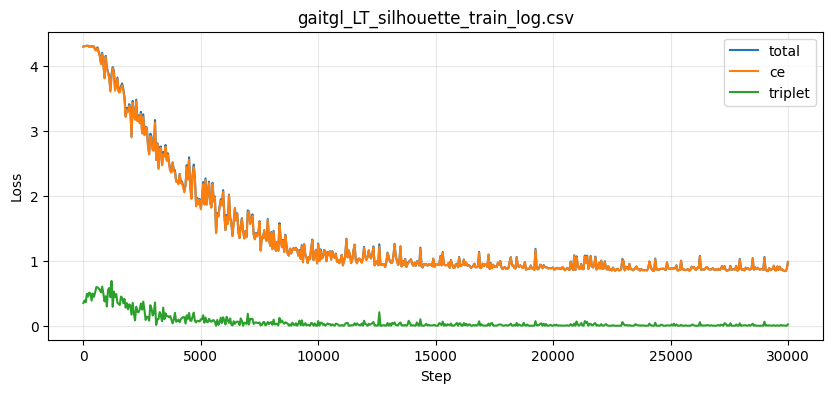

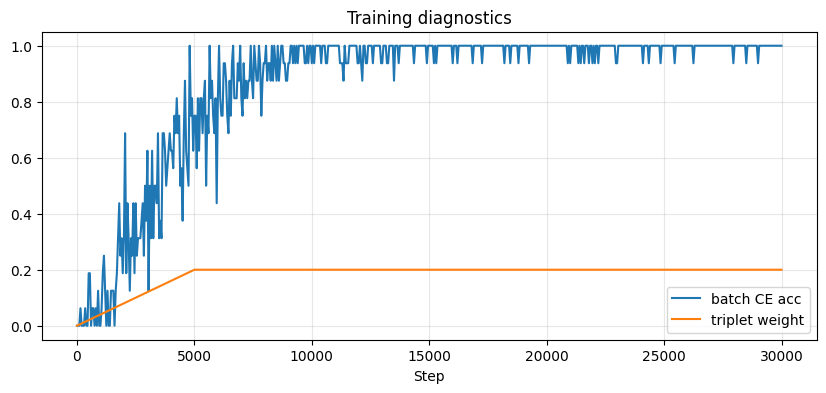

In [9]:
# ============================================================
# CELL 9 — Inspect latest full training log
# ============================================================

log_files = sorted(LOG_DIR.glob(f"{RUN_NAME}*_train_log.csv"))

print("Training log files:")
for p in log_files:
    print("-", p.name)

# Prefer full training log over tiny if available.
full_logs = [p for p in log_files if "_tiny_" not in p.name and p.name == f"{RUN_NAME}_train_log.csv"]
latest_log = full_logs[-1] if full_logs else (log_files[-1] if log_files else None)

if latest_log is not None:
    df_log_latest = pd.read_csv(latest_log)

    print("Latest log:", latest_log)
    display(df_log_latest.head())
    display(df_log_latest.tail())

    if len(df_log_latest) > 0:
        print("First total loss:", df_log_latest["loss"].iloc[0])
        print("Last total loss :", df_log_latest["loss"].iloc[-1])
        print("Min total loss  :", df_log_latest["loss"].min())
        print("Last batch acc  :", df_log_latest["train_batch_acc"].iloc[-1])

        plt.figure(figsize=(10, 4))
        plt.plot(df_log_latest["step"], df_log_latest["loss"], label="total")
        if "ce_loss" in df_log_latest.columns:
            plt.plot(df_log_latest["step"], df_log_latest["ce_loss"], label="ce")
        if "triplet_loss" in df_log_latest.columns:
            plt.plot(df_log_latest["step"], df_log_latest["triplet_loss"], label="triplet")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title(latest_log.name)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(df_log_latest["step"], df_log_latest["train_batch_acc"], label="batch CE acc")
        if "triplet_weight" in df_log_latest.columns:
            plt.plot(df_log_latest["step"], df_log_latest["triplet_weight"], label="triplet weight")
        plt.xlabel("Step")
        plt.title("Training diagnostics")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
else:
    print("No logs found.")

In [10]:
# ============================================================
# CELL 10 — List checkpoints
# ============================================================

ckpt_files = sorted(CHECKPOINT_DIR.glob(f"{RUN_NAME}*.pth"))

print("Checkpoints:")
for p in ckpt_files:
    print("-", p.name)

Checkpoints:
- gaitgl_LT_silhouette_best_loss.pth
- gaitgl_LT_silhouette_best_train_acc.pth
- gaitgl_LT_silhouette_full_last.pth
- gaitgl_LT_silhouette_last.pth
- gaitgl_LT_silhouette_step_1000.pth
- gaitgl_LT_silhouette_step_10000.pth
- gaitgl_LT_silhouette_step_11000.pth
- gaitgl_LT_silhouette_step_12000.pth
- gaitgl_LT_silhouette_step_13000.pth
- gaitgl_LT_silhouette_step_14000.pth
- gaitgl_LT_silhouette_step_15000.pth
- gaitgl_LT_silhouette_step_16000.pth
- gaitgl_LT_silhouette_step_17000.pth
- gaitgl_LT_silhouette_step_18000.pth
- gaitgl_LT_silhouette_step_19000.pth
- gaitgl_LT_silhouette_step_2000.pth
- gaitgl_LT_silhouette_step_20000.pth
- gaitgl_LT_silhouette_step_21000.pth
- gaitgl_LT_silhouette_step_22000.pth
- gaitgl_LT_silhouette_step_23000.pth
- gaitgl_LT_silhouette_step_24000.pth
- gaitgl_LT_silhouette_step_25000.pth
- gaitgl_LT_silhouette_step_26000.pth
- gaitgl_LT_silhouette_step_27000.pth
- gaitgl_LT_silhouette_step_28000.pth
- gaitgl_LT_silhouette_step_29000.pth
- gai

## After full training

Recommended next notebook:

```text
11_evaluate_silhouette_gaitgl_expert.ipynb
```

For evaluation, use:

```text
checkpoints/gaitgl_LT_silhouette_last.pth
```

or compare:

```text
checkpoints/gaitgl_LT_silhouette_best_loss.pth
checkpoints/gaitgl_LT_silhouette_best_train_acc.pth
```

Expected input splits:

```text
data/fusion_splits/gallery_LT_fusion.csv
data/fusion_splits/probe_LT_nm_fusion.csv
data/fusion_splits/probe_LT_bg_fusion.csv
data/fusion_splits/probe_LT_cl_fusion.csv
```

Important: gallery may be 2197 instead of 2200 because bad/very-short samples were removed. Evaluation script must use dynamic gallery length.